## ИИММ: практическая работа 6

Суть задания:  
Предстоит найти или записать видео с объектом класса из практической работы 5, а затем протестировать работу различных методов трекинга объектов на различных задачах.

План работы:  
1. Запуск трекинга ByteTrack на своем видео со своей моделью.
2. Подсчет попадания объекта в RoI.
3. Сравнение трекинга из ПР1 с трекингом с помощью ByteTrack.
4. Оценка скорости объекта.
5. Оценка точности трекинга.
6. Реализация реидентификации.

### Этап 1. Запуск трекинга ByteTrack с собственной моделью

In [7]:
from ultralytics import YOLO

detector = YOLO("./yolo_custom.pt")

In [3]:
import cv2

cap = cv2.VideoCapture("./input.mp4")
writer = cv2.VideoWriter('./output_det.mp4', # путь к файлу
                         cv2.VideoWriter_fourcc(*'MPEG'), # кодек
                         25, # FPS
                         (int(cap.get(3)),int(cap.get(4))) # разрешение
                        )

assert cap.isOpened()

In [4]:
def draw_detections(frame, detections):
  frame_with_detections = frame.copy() # делаем .copy(), т.к. без этого мы просто получим ссылку на оригинальную переменную
  h, w = frame_with_detections.shape[:2]
  label_lines = []
  if detections.boxes is not None:
    for box in detections.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        cx = ((x1 + x2) / 2) / w
        cy = ((y1 + y2) / 2) / h
        bw = (x2 - x1) / w
        bh = (y2 - y1) / h
        label_lines.append(f"0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")
        cv2.rectangle(
            frame_with_detections,
            (int(x1), int(y1)),
            (int(x2), int(y2)),
            (0, 255, 0),
            2
        )
        cv2.putText(frame_with_detections,
            "Rick and Morty: Morty",
            (int(x1), int(y1) - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

  return frame_with_detections

In [5]:
while cap.isOpened():
  ret, frame = cap.read()

  if not ret:
    break

  results = detector.predict(frame, verbose=False, classes=[0], conf=0.8)
  detections_frame = draw_detections(frame, results[0])

  writer.write(detections_frame)

cap.release()
writer.release()

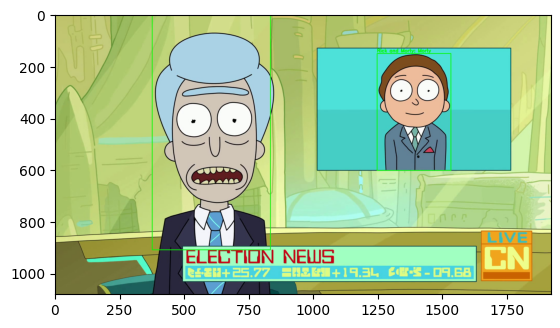

In [6]:
import matplotlib.pyplot as plt

cap = cv2.VideoCapture('./output_det.mp4')
cap.set(cv2.CAP_PROP_POS_FRAMES, 200)

ret, frame = cap.read()

frame_to_show = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.imshow(frame_to_show)

In [1]:
from boxmot.trackers.bytetrack.bytetrack import ByteTrack

tracker = ByteTrack()

SUCCESS  | ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, track_thresh=0.45, match_thresh=0.8, track_buffer=25, frame_rate=30


In [2]:
import numpy as np

def convert_yolo_numpy(detections):
  numpy_detections = []
  h, w = 1080, 1920
  if detections is not None:
    for box in detections:
        x1, y1, x2, y2 = box.xyxy[0].cpu()
        numpy_detections.append([x1, y1, x2, y2, float(box.conf), int(box.cls)])
  return np.array(numpy_detections)

In [3]:
from random import randint

def draw_tracks_bytetrack(frame, detections, tracks):
  tracked_frame = frame.copy()
  ids = []
  for box in detections:
    x1, y1, x2, y2 = box[0], box[1], box[2], box[3]
    cx = ((x1 + x2) / 2)
    cy = ((y1 + y2) / 2)
    cv2.rectangle(
        tracked_frame,
        (int(x1), int(y1)),
        (int(x2), int(y2)),
        (0, 255, 0),
        2
    )
    cv2.putText(tracked_frame,
        f"{box[6]} Morty: {box[4]}",
        (int(x1), int(y1) - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )
    if box[4] not in ids:
       ids.append(box[4])
    if tracks.get(box[4]) is None:
       tracks[box[4]] = [(randint(128, 255), randint(128, 255), randint(128, 255))]
    tracks[box[4]].append((int(cx), int(cy)))
  tracks = {k: v for k, v in tracks.items() if k in ids}
  for id in tracks.keys():
      for c in tracks[id][1:]:
        cv2.drawMarker(tracked_frame, c, color=tracks[id][0], thickness=1,
                  markerType=cv2.MARKER_STAR, line_type=cv2.LINE_AA, markerSize=16)
  return tracked_frame

In [4]:
import cv2

cap = cv2.VideoCapture("./input.mp4")
writer = cv2.VideoWriter('./output_track.mp4', cv2.VideoWriter_fourcc(*'MPEG'), 25, (int(cap.get(3)),int(cap.get(4))))

assert cap.isOpened()

In [8]:
tracks = {}
while cap.isOpened():
  ret, frame = cap.read()

  if not ret:
    break

  results = detector.predict(frame, verbose=False)
  numpy_detections = convert_yolo_numpy(results[0].boxes)
  detections = tracker.update(numpy_detections, frame)

  tracked_frame = draw_tracks_bytetrack(frame, detections, tracks)

  writer.write(tracked_frame)

cap.release()
writer.release()

### Этап 2. Подсчет попадания объекта в RoI

In [ ]:
!curl -L -o ./area_count.mp4 https://drive.google.com/uc?id=1-cFmI5i5KNs-BY3cQH2CQ7IxHR4nnhSb

In [ ]:
import cv2

cap = cv2.VideoCapture('./area_count.mp4')
writer = cv2.VideoWriter('./detections_in_area.mp4',
                         cv2.VideoWriter_fourcc(*'MPEG'),
                         25,
                         (int(cap.get(3)),int(cap.get(4)))
                        )

assert cap.isOpened()

# Подберите X и Y для повторения области из примера
area_top_left = (408, 0)
area_bottom_right = (510, 184)

In [ ]:
from ultralytics import YOLO
from boxmot.trackers.bytetrack.bytetrack import ByteTrack

detector = YOLO('yolov8m.pt')
tracker = ByteTrack()

SUCCESS  | ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, track_thresh=0.45, match_thresh=0.8, track_buffer=25, frame_rate=30


In [ ]:
def get_detections_in_area(tracked_detections, area_top_left, area_bottom_right):
  area_xmin, area_ymin = area_top_left
  area_xmax, area_ymax = area_bottom_right

  detections_in_area = []

  for d in tracked_detections:
    if d[6] != 0:
      continue
    xmin, ymin, xmax, ymax, id = d[0], d[1], d[2], d[3], d[4]
    if ((area_xmin < xmin < area_xmax or area_xmin < xmax < area_xmax) 
        and (area_ymin < ymin < area_ymax or area_ymin < ymax < area_ymax)):
      detections_in_area.append(int(id))
    
  return detections_in_area

In [ ]:
counter = 0
ids = []

In [ ]:
def process_frame(frame, detections):

  global counter
  global ids
  tracked_frame = frame.copy()
  cv2.rectangle(
      tracked_frame,
      area_top_left,
      area_bottom_right,
      (255, 0, 0),
      2
  )

  for box in detections:
    if box[6] != 0:
      continue
    x1, y1, x2, y2 = box[0], box[1], box[2], box[3]
    cv2.rectangle(
        tracked_frame,
        (int(x1), int(y1)),
        (int(x2), int(y2)),
        (0, 255, 0),
        2
    )
    cv2.putText(tracked_frame,
        f"{box[4]}",
        (int(x1), int(y1) - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.2,
        (0, 255, 0),
        1
    )
    
  det_ids = get_detections_in_area(detections, area_top_left=area_top_left,
                                   area_bottom_right=area_bottom_right)
  for i in det_ids:
    if i not in ids:
      ids.append(i)
      counter += 1

  cv2.putText(tracked_frame,
      str(counter),
      (25, 25),
      cv2.FONT_HERSHEY_SIMPLEX,
      0.6,
      (0, 255, 0),
      2
  )

  return tracked_frame

In [ ]:
while cap.isOpened():
  ret, frame = cap.read()

  if not ret:
    break

  detections = detector.predict(frame, verbose=False)
  numpy_detections = convert_yolo_numpy(detections[0].boxes)
  tracks = tracker.update(numpy_detections, frame)

  roi_frame = process_frame(frame, tracks)
  writer.write(roi_frame)

cap.release()
writer.release()

In [ ]:
counter

9

### Этап 3. Сравнение трекинга из ПР1 с нынешним

In [18]:
import cv2

def find_centroid(img):
  contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  if len(contours) > 0:
    largest_contour = max(contours, key=cv2.contourArea)
    moments = cv2.moments(largest_contour)
    if moments["m00"] != 0:
        cx = int(moments["m10"] / moments["m00"])
        cy = int(moments["m01"] / moments["m00"])
    else:
        cx, cy = 0, 0
    return (cx, cy)
  return None


cap = cv2.VideoCapture('./inrange_input.mp4') # путь к видео с результатами работы ByteTrack
writer = cv2.VideoWriter('./inrange_track.mp4',
                         cv2.VideoWriter_fourcc(*'MPEG'),
                         25,
                         (int(cap.get(3)),int(cap.get(4)))
                        )

assert cap.isOpened()

coordinates = []

while cap.isOpened():
  ret, frame = cap.read()

  if not ret:
    break

  frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
  image_thresholded = cv2.inRange(cv2.cvtColor(frame, cv2.COLOR_BGR2HSV), (23, 25, 80), (27, 45, 110))
  coordinates.append(find_centroid(image_thresholded))

  for c in coordinates:
    cv2.drawMarker(frame_rgb, c, color=(255, 0, 0), thickness=2,
      markerType=cv2.MARKER_STAR, line_type=cv2.LINE_AA, markerSize=15)
  
  frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)

  writer.write(frame_bgr)

cap.release()
writer.release()